In [ ]:
#!pip install pandas Jinja2 matplotlib seaborn scikit-learn xgboost

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin

import joblib

from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.model_selection import GridSearchCV

# 01. Dataset Analysis

In [ ]:
df = pd.read_csv('data/customer_churn_business_dataset.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  str    
 1   gender                  10000 non-null  str    
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  str    
 4   city                    10000 non-null  str    
 5   customer_segment        10000 non-null  str    
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  str    
 8   contract_type           10000 non-null  str    
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 14  last_login_days_ago     10000 non-null  int64  
 1

In [4]:
df.head()

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


Checking the unique values of each column for more data understanding

In [ ]:
summary_data = []
for col in df.columns:
    null_count = df[col].isnull().sum()
    null_pct = (null_count / len(df)) * 100
    top_5 = df[col].value_counts().index[:5].tolist()
    sample_str = ", ".join(map(str, top_5))
    
    summary_data.append({
        'Column': col,
        'Dtype': str(df[col].dtype),
        'Unique': df[col].nunique(),
        'Null_Count': null_count,
        'Null_%': f"{null_pct:.2f}%",
        'Sample_Values': sample_str
    })

summary_df = pd.DataFrame(summary_data)
summary_df

,Column,Dtype,Unique,Null_Count,Null_%,Sample_Values
0,gender,str,2,0,0.00%,"Male, Female"
1,age,int64,57,0,0.00%,"30, 43, 33, 65, 74, 34, 56, 40"
2,country,str,7,0,0.00%,"Bangladesh, Canada, USA, India, Australia, UK,..."
3,city,str,7,0,0.00%,"London, Sydney, Dhaka, Delhi, Berlin, New_York..."
4,customer_segment,str,3,0,0.00%,"Individual, SME, Enterprise"
5,tenure_months,int64,59,0,0.00%,"58, 36, 22, 42, 30, 29, 51, 34"
6,signup_channel,str,3,0,0.00%,"Web, Mobile, Referral"
7,contract_type,str,3,0,0.00%,"Monthly, Quarterly, Yearly"
8,monthly_logins,int64,53,0,0.00%,"17, 21, 22, 23, 19, 18, 20, 25"
9,weekly_active_days,int64,8,0,0.00%,"0, 5, 2, 6, 4, 7, 1, 3"


By looking at this table, I can see all the str can be categorical and also missing values only exists for complaint_type, and that should be because usually users don't fill those forms even when leaving the service.

In [6]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,10000,10000,CUST_00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,10000,2,Male,5013,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,10000.0,NaN,NaN,NaN,45.9061,16.420416,18.0,32.0,46.0,60.0,74.0
country,10000,7,Bangladesh,1494,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,10000,7,London,1518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_segment,10000,3,Individual,5984,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure_months,10000.0,NaN,NaN,NaN,30.1557,17.099517,1.0,16.0,30.0,45.0,59.0
signup_channel,10000,3,Web,5036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contract_type,10000,3,Monthly,4967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_logins,10000.0,NaN,NaN,NaN,19.672,9.838003,0.0,13.0,20.0,26.0,54.0


In [7]:
df.columns

Index(['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment',
       'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins',
       'weekly_active_days', 'avg_session_time', 'features_used',
       'usage_growth_rate', 'last_login_days_ago', 'monthly_fee',
       'total_revenue', 'payment_method', 'payment_failures',
       'discount_applied', 'price_increase_last_3m', 'support_tickets',
       'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations',
       'email_open_rate', 'marketing_click_rate', 'nps_score',
       'survey_response', 'referral_count', 'churn'],
      dtype='str')

### Missing Values

From the above summary table, there werent any missing data for float or int, which is good but I would like to check str for missing or "bad" values for it.

In [8]:
summary_data = []
for col in df.columns:
    if str(df[col].dtype) == 'str':
        null_count = df[col].isnull().sum()
        null_pct = (null_count / len(df)) * 100
        top_5 = df[col].value_counts().index[:7].tolist()
        sample_str = ", ".join(map(str, top_5))
        
        summary_data.append({
            'Column': col,
            'Dtype': str(df[col].dtype),
            'Unique': df[col].nunique(),
            'Null_Count': null_count,
            'Null_%': f"{null_pct:.2f}%",
            'Sample_Values': sample_str
        })

summary_df = pd.DataFrame(summary_data)
summary_df

,Column,Dtype,Unique,Null_Count,Null_%,Sample_Values
0,customer_id,str,10000,0,0.00%,"CUST_00001, CUST_00002, CUST_00003, CUST_00004..."
1,gender,str,2,0,0.00%,"Male, Female"
2,country,str,7,0,0.00%,"Bangladesh, Canada, USA, India, Australia, UK,..."
3,city,str,7,0,0.00%,"London, Sydney, Dhaka, Delhi, Berlin, New York..."
4,customer_segment,str,3,0,0.00%,"Individual, SME, Enterprise"
5,signup_channel,str,3,0,0.00%,"Web, Mobile, Referral"
6,contract_type,str,3,0,0.00%,"Monthly, Quarterly, Yearly"
7,payment_method,str,3,0,0.00%,"Card, PayPal, Bank Transfer"
8,discount_applied,str,2,0,0.00%,"No, Yes"
9,price_increase_last_3m,str,2,0,0.00%,"No, Yes"


All strings looks fine in the sense of proper values that are good for categories. Again the complain_type shouldnt be treated as a data quality issue, instead it is likely the users never submitted a complaint. My idea now is to treat it as "No Complaints" category along with "Technical, Billing, Service" categories that already exisits for column.

Also some strings have white spaces in them, which could cause some issues or not, but I like to replace them with underscores

In [9]:
df.columns = df.columns.str.replace(' ', '_') #Replcaing white spaces if there any

for col in df.columns:
    if  str(df[col].dtype) == 'str':
        df[col] = df[col].str.replace(' ', '_', regex=True)

print(df['payment_method'].unique())

<StringArray>
['PayPal', 'Card', 'Bank_Transfer']
Length: 3, dtype: str


### Target Variable

In [10]:
sum(df["churn"]) / len(df["churn"])

0.1021

There is around 10% users that has left, it shows there is a class imbalance for the target data

C:\Users\Fenaz\AppData\Local\Temp\ipykernel_39712\279872225.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


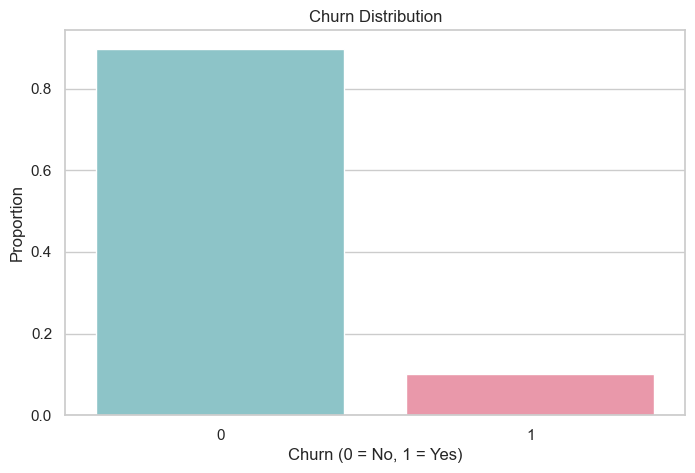

In [11]:

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

churn_dist = df["churn"].value_counts(normalize=True)


sns.barplot(
    x=churn_dist.index,
    y=churn_dist.values,
    palette=["#83CCD2", "#F68BA2"]
)
plt.title("Churn Distribution")
plt.ylabel("Proportion")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.show()

### "What effects the Churn?" Analysis

#### 01. Demogrophic Analysis

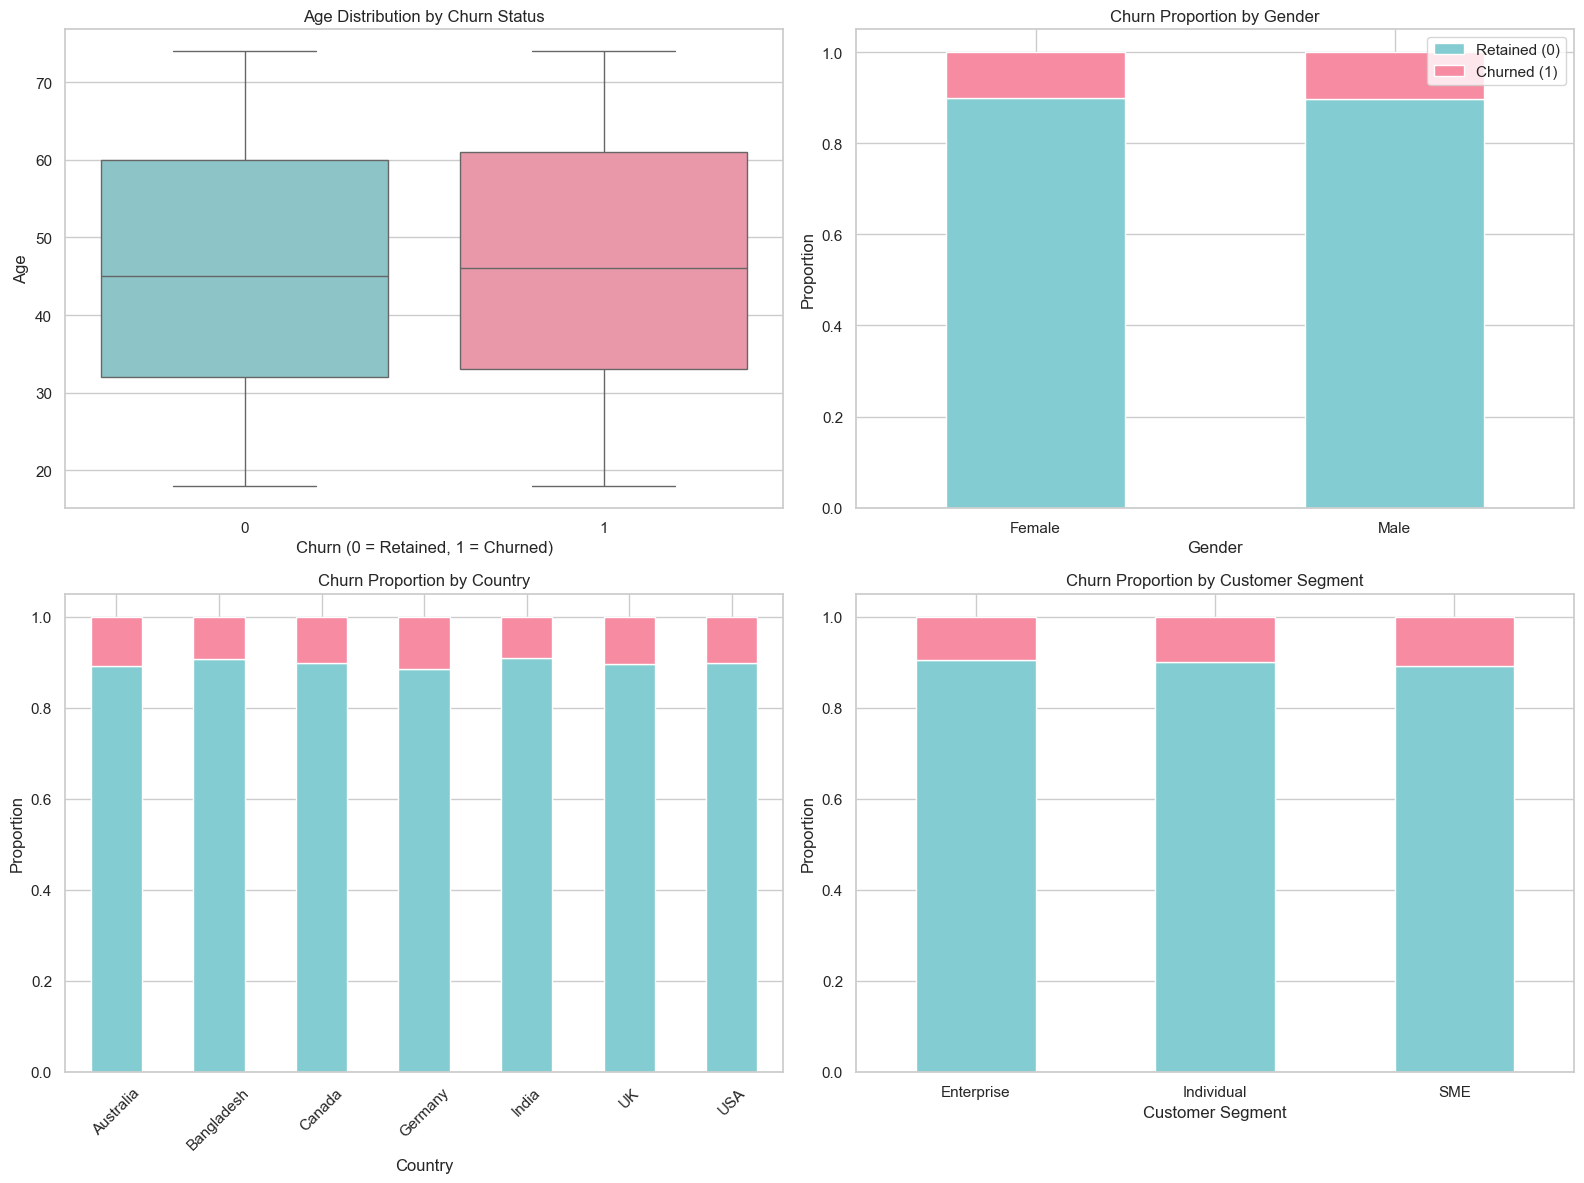

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = ["#83CCD2", "#F68BA2"]

# 1. Top Left: Age Distribution (Boxplot)
sns.boxplot(
    data=df, 
    x="churn", 
    y="age", 
    hue="churn",  
    palette=colors,
    legend=False,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Age Distribution by Churn Status")
axes[0, 0].set_xlabel("Churn (0 = Retained, 1 = Churned)")
axes[0, 0].set_ylabel("Age")

# 2. Top Right: Gender Churn Rate 
gender_churn = pd.crosstab(df["gender"], df["churn"], normalize="index")
gender_churn.plot(kind="bar", stacked=True, color=colors, ax=axes[0, 1])

axes[0, 1].set_title("Churn Proportion by Gender")
axes[0, 1].set_ylabel("Proportion")
axes[0, 1].set_xlabel("Gender")
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(["Retained (0)", "Churned (1)"], loc="upper right")

# 3. Bottom Left: Country Churn Rate (Stacked Bar)
country_churn = pd.crosstab(df["country"], df["churn"], normalize="index")
country_churn.plot(kind="bar", stacked=True, color=colors, ax=axes[1, 0])

axes[1, 0].set_title("Churn Proportion by Country")
axes[1, 0].set_ylabel("Proportion")
axes[1, 0].set_xlabel("Country")
axes[1, 0].tick_params(axis='x', rotation=45) 
axes[1, 0].get_legend().remove() 

# 4. Bottom Right: Customer Segment Churn Rate (Stacked Bar)
segment_churn = pd.crosstab(df["customer_segment"], df["churn"], normalize="index")
segment_churn.plot(kind="bar", stacked=True, color=colors, ax=axes[1, 1])

axes[1, 1].set_title("Churn Proportion by Customer Segment")
axes[1, 1].set_ylabel("Proportion")
axes[1, 1].set_xlabel("Customer Segment")
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].get_legend().remove()


plt.tight_layout()
plt.show()

These visuals suggests there is no significant impact on churn rate due to demographics of the user, except for their country.

#### 02. Tenure and Contract Ananlysis

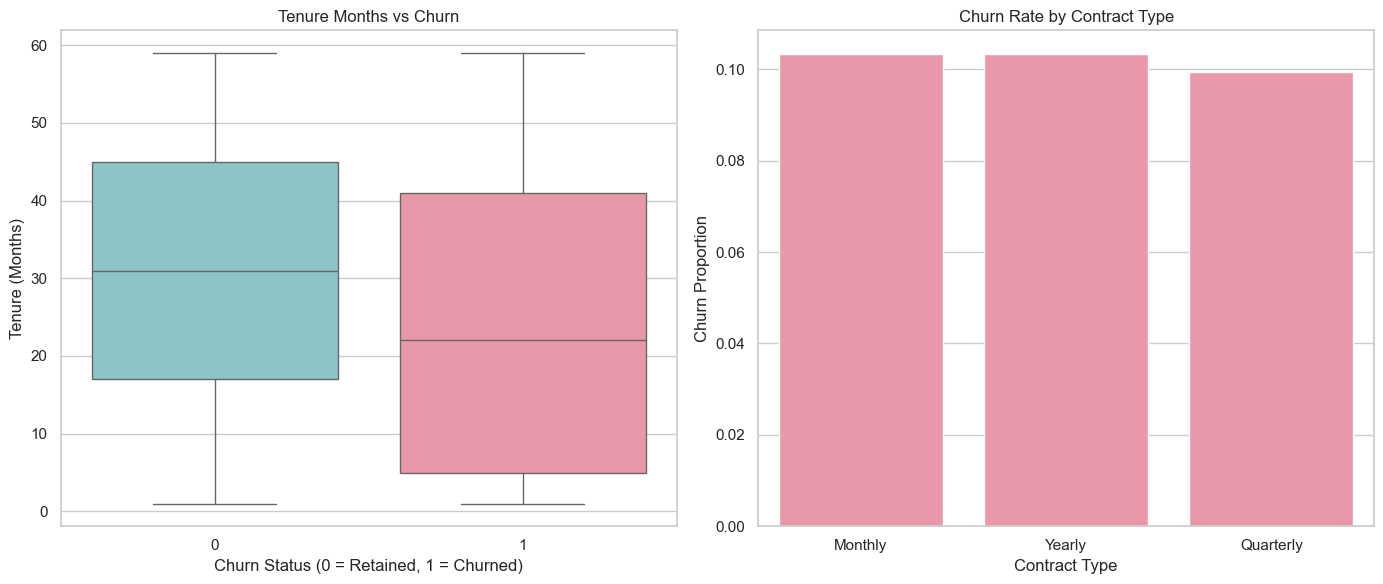

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


# Tenure Months vs Churn (Boxplot)
sns.boxplot(
    data=df,
    x="churn",
    y="tenure_months",
    hue="churn",  
    palette=["#83CCD2", "#F68BA2"],
    legend=False, 
    ax=axes[0]
)
axes[0].set_title("Tenure Months vs Churn")
axes[0].set_xlabel("Churn Status (0 = Retained, 1 = Churned)")
axes[0].set_ylabel("Tenure (Months)")


# Churn Rate by Contract Type (Barplot)
sns.barplot(
    data=df,
    x="contract_type",
    y="churn",
    color="#F68BA2", 
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title("Churn Rate by Contract Type")
axes[1].set_ylabel("Churn Proportion")
axes[1].set_xlabel("Contract Type")

plt.tight_layout()
plt.show()

Users tend to leave only early months, could be due to onboarding issue

Quarterly contracts seems to have slightly lower churns


#### 03. Logins and Usage

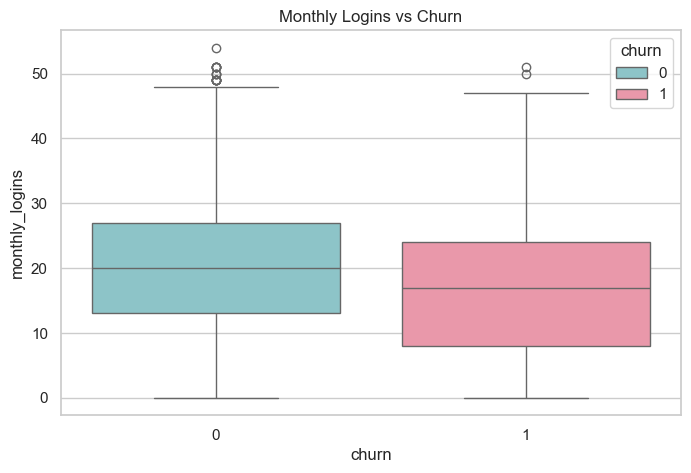

In [14]:
sns.boxplot(
    x="churn",
    y="monthly_logins",
    data=df,
    hue="churn",  
    palette=["#83CCD2", "#F68BA2"]
)
plt.title("Monthly Logins vs Churn")
plt.show()

Churned users seems to have lower logins

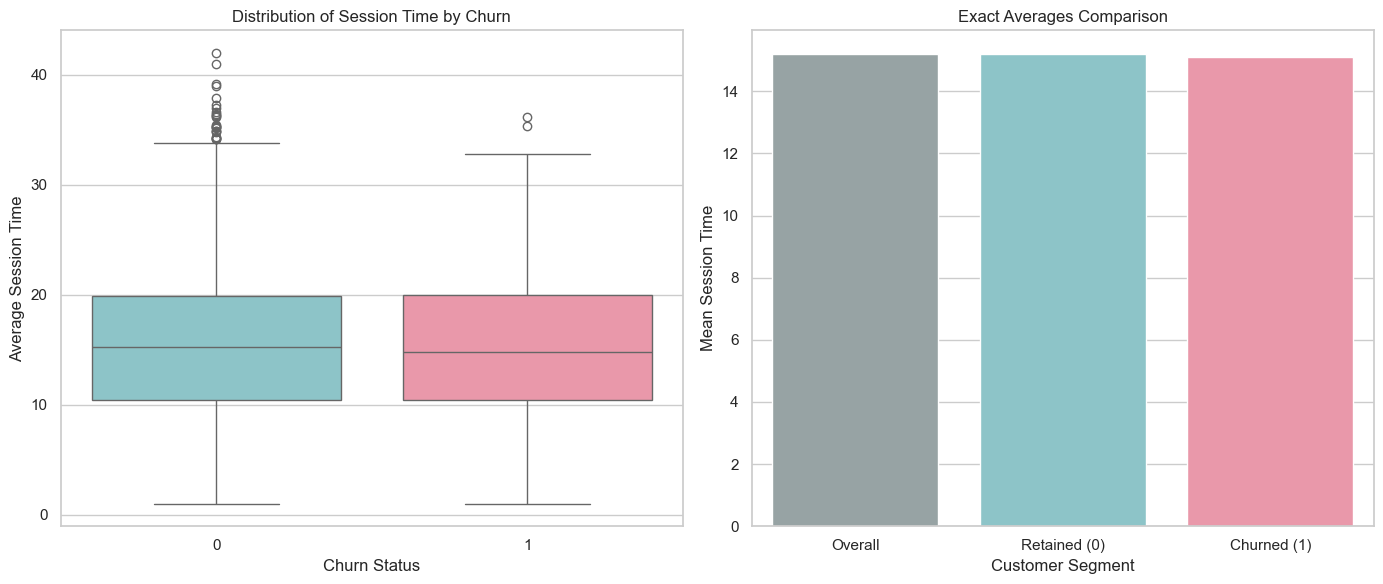

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Avereage Session time vs Churn
sns.boxplot(
    data=df, 
    x="churn", 
    y="avg_session_time", 
    hue="churn",
    palette=["#83CCD2", "#F68BA2"],
    legend=False,
    ax=axes[0] 
)
axes[0].set_title("Distribution of Session Time by Churn")
axes[0].set_ylabel("Average Session Time")
axes[0].set_xlabel("Churn Status")

#Overall vs Segmented Averages (Barplot)
overall_avg = df["avg_session_time"].mean()
retained_avg = df[df["churn"] == 0]["avg_session_time"].mean()
churned_avg = df[df["churn"] == 1]["avg_session_time"].mean()


avg_df = pd.DataFrame({
    "Group": ["Overall", "Retained (0)", "Churned (1)"],
    "Mean Session Time": [overall_avg, retained_avg, churned_avg]
})


sns.barplot(
    data=avg_df, 
    x="Group", 
    y="Mean Session Time", 
    hue="Group",
    palette=["#95a5a6","#83CCD2", "#F68BA2"], 
    legend=False,
    ax=axes[1] 
)
axes[1].set_title("Exact Averages Comparison")
axes[1].set_ylabel("Mean Session Time")
axes[1].set_xlabel("Customer Segment")

plt.tight_layout()
plt.show()

Avereage useage time doesnt seem to effecting churns

#### 04. Support Tickets and Satisfaction Scores

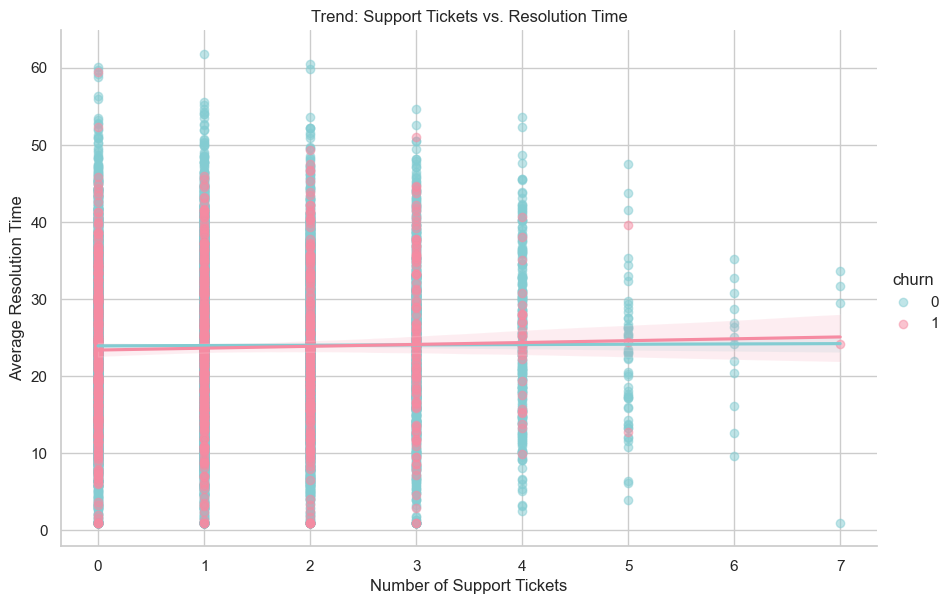

In [16]:
sns.lmplot(
    data=df,
    x="support_tickets",
    y="avg_resolution_time",
    hue="churn",
    palette=["#83CCD2", "#F68BA2"],
    scatter_kws={'alpha': 0.5}, 
    height=6,    
    aspect=1.5   
)

plt.title("Trend: Support Tickets vs. Resolution Time")
plt.xlabel("Number of Support Tickets")
plt.ylabel("Average Resolution Time")
plt.show()

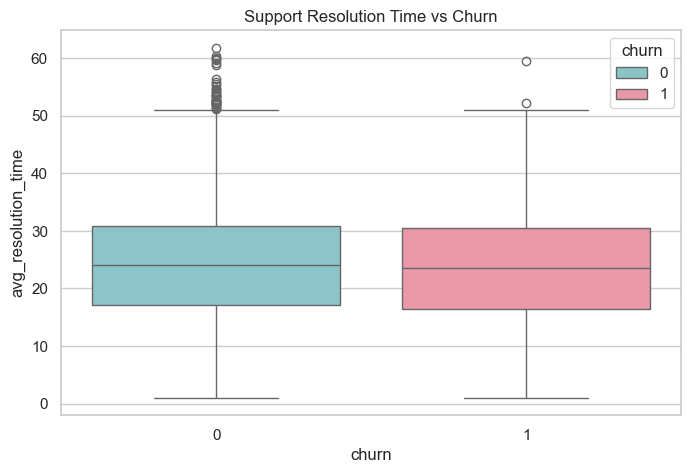

In [17]:
sns.boxplot(
    x="churn",
    y="avg_resolution_time",
    data=df,
    hue="churn",
    palette=["#83CCD2", "#F68BA2"], 
)
plt.title("Support Resolution Time vs Churn")
plt.show()

This kinda seems wrong, I was expecting for those who had longer resolution time and more support tickets, the churn would be higher but it doesnt seems like that in this dataset

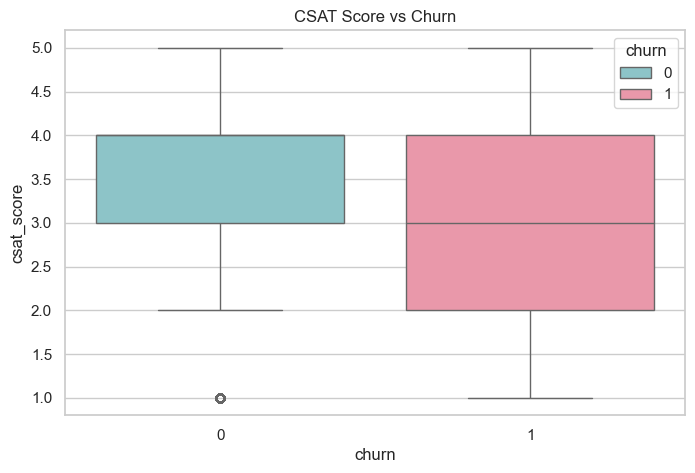

In [18]:
sns.boxplot(
    x="churn",
    y="csat_score",
    data=df,
    palette=["#83CCD2", "#F68BA2"], 
    hue="churn",
)
plt.title("CSAT Score vs Churn")
plt.show()

The satisfaction score has strong association with churned customers

#### 04. Revenue from the Users Analysis

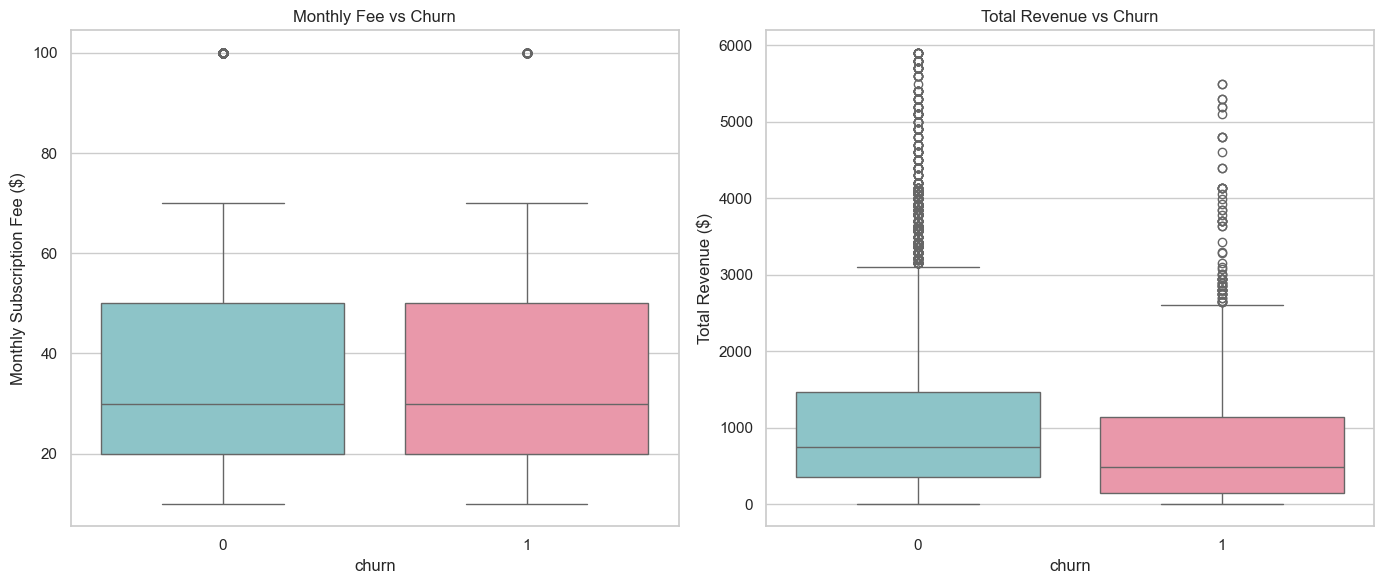

In [19]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
palette = palette=["#83CCD2", "#F68BA2"]

sns.boxplot(
    data=df, 
    x="churn", 
    y="monthly_fee", 
    hue="churn", 
    palette=palette,
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Monthly Fee vs Churn")
axes[0].set_ylabel("Monthly Subscription Fee ($)")


sns.boxplot(
    data=df, 
    x="churn", 
    y="total_revenue", 
    hue="churn", 
    palette=palette,
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Total Revenue vs Churn")
axes[1].set_ylabel("Total Revenue ($)")

plt.tight_layout()
plt.show()

Low revenue indicates towards customers leaving

## 02. Feature Engineering

Before transformations, I like to keep an original uneffected copy of df

In [20]:
df_original = df.copy() 

### Transformation 1 - total_support_wait_time

New column that shows how long their tickets take to get solved, the total numbere of time they have waited could show how satisfied they are with the product

In [21]:
df['total_support_wait_time'] = df['support_tickets'] * df['avg_resolution_time']

### Transformation 2 - Support Rate

The CSAT score is stronly impacting the churning, hence I made a unhappy flag for lower CSAT, also support tickets that are escalated to manager would be more serious compared to just the number of tickets, by finding the rate of escalation for the tickets, there could be some better understanding

In [22]:
df["unhappy_flag"] = (df["csat_score"] <= 3).astype(int)

df["escalation_rate"] = (
    (df["support_tickets"] + df["escalations"]) /
    (df["tenure_months"] + 1)
)


### Transformation 3 - engagement_score

Percentile ranking for columns that could be related to engagment and flag for low login using monthly_logins below median

In [23]:
df["engagement_score"] = (
    df["monthly_logins"].rank(pct=True) +
    df["weekly_active_days"].rank(pct=True) +
    df["avg_session_time"].rank(pct=True)
)

login_median = df["monthly_logins"].median()

df["low_engagement_flag"] = (
    (df["monthly_logins"] < login_median)
).astype(int)

### Transformation 4- Handling Missing Complaint Type

Assuming the blank complain type meaning there wasn't any complaints, I filled them with "No_Complaint" values

In [24]:
df["complaint_type"] = df["complaint_type"].fillna("No_Complaint")

In [25]:
df.head()

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,marketing_click_rate,nps_score,survey_response,referral_count,churn,total_support_wait_time,unhappy_flag,escalation_rate,engagement_score,low_engagement_flag
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,0.40,27,Satisfied,1,0,53.417439,0,0.173913,1.99440,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,0.33,-19,Neutral,2,1,25.140088,1,0.100000,1.74605,1
2,CUST_00003,Male,24,Germany,New_York,SME,58,Web,Yearly,19,...,0.49,80,Neutral,1,0,27.572928,1,0.016949,2.05270,1
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,0.15,100,Neutral,0,0,79.262467,0,0.200000,2.76955,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,0.44,21,Unsatisfied,1,0,0.000000,0,0.000000,2.03155,0


### Transformation 4- Handling Customer_Id

In [26]:
cols_to_drop = ['customer_id']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

### EDA For New Columns

C:\Users\Fenaz\AppData\Local\Temp\ipykernel_39712\1473725975.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(["Satisfied (0)", "Unhappy (1)"])
C:\Users\Fenaz\AppData\Local\Temp\ipykernel_39712\1473725975.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(["Normal/High (0)", "Low Engagement (1)"])


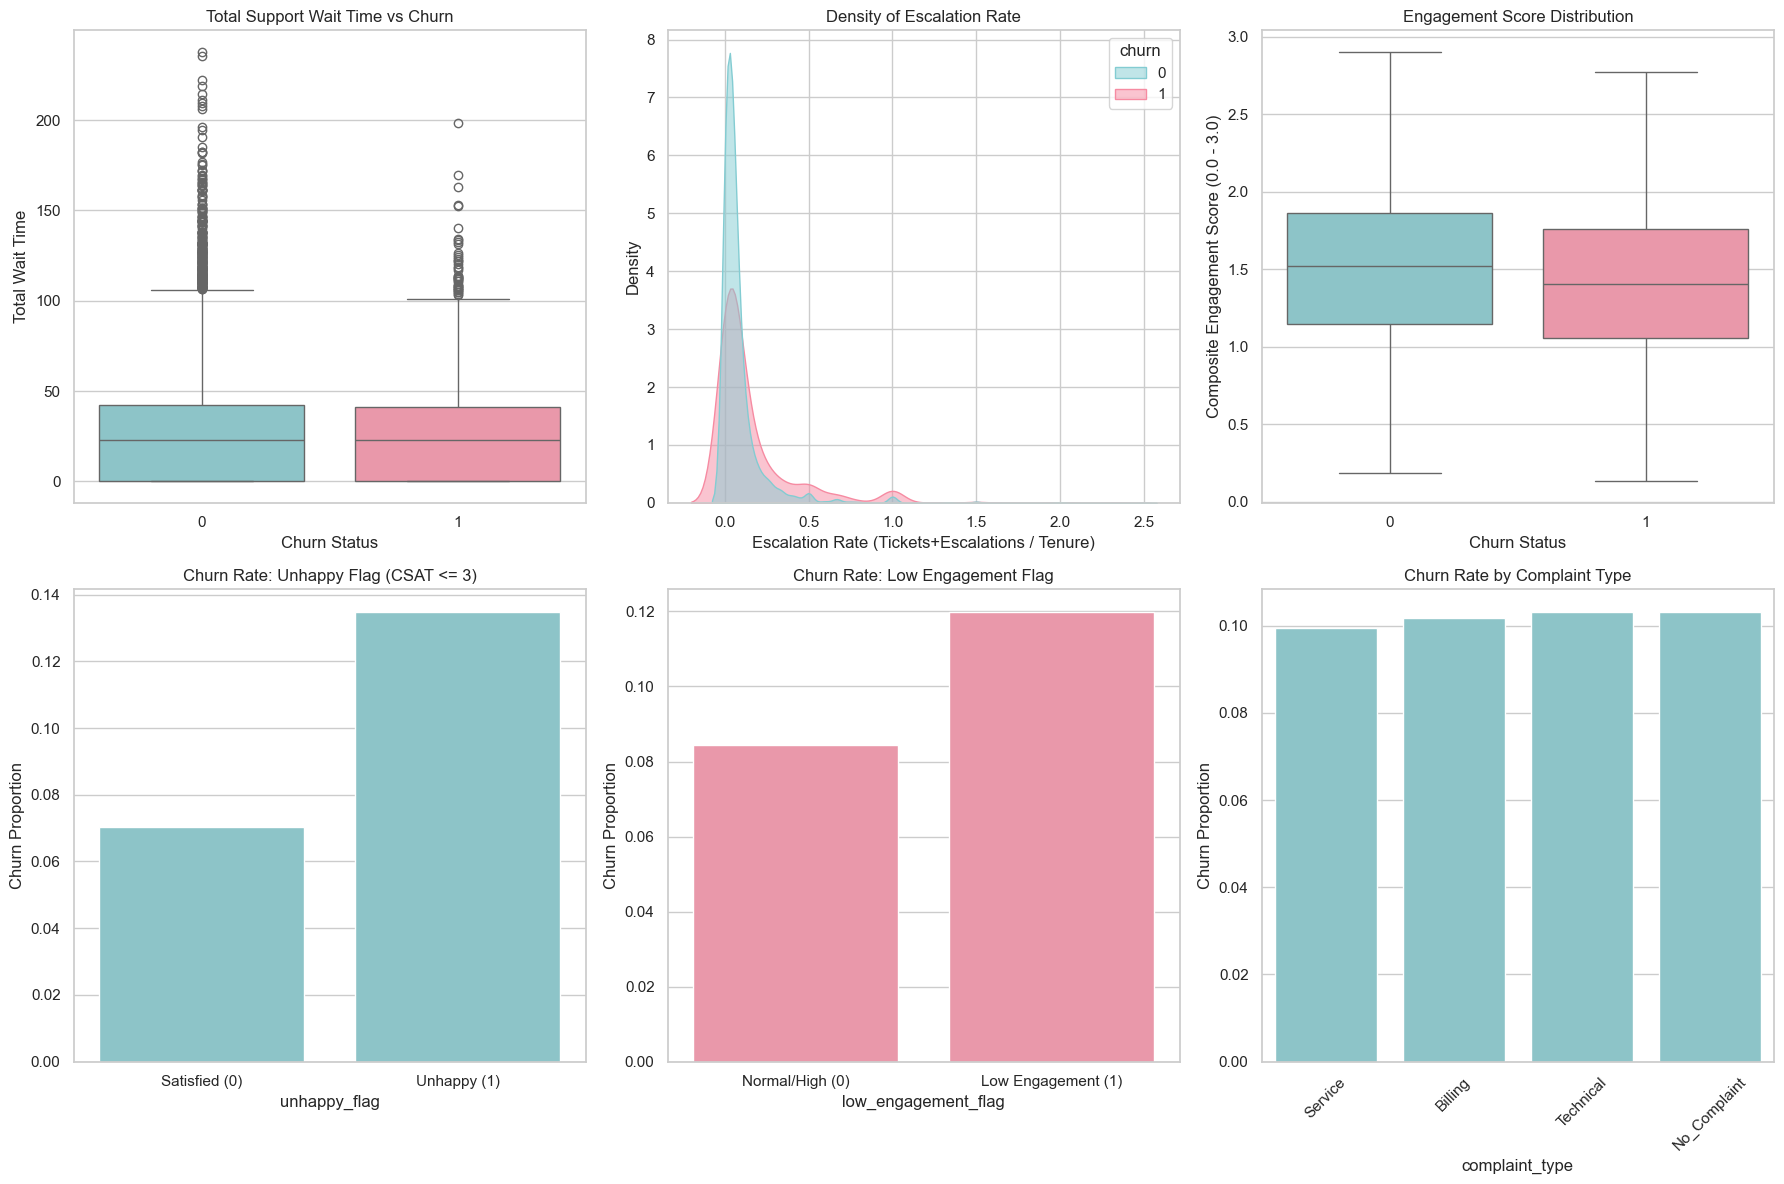

In [27]:

fig, axes = plt.subplots(2, 3, figsize=(18, 12))


# 1. Total Support Wait Time
sns.boxplot(data=df, x="churn", y="total_support_wait_time", hue="churn", palette=palette, legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Total Support Wait Time vs Churn")
axes[0, 0].set_xlabel("Churn Status")
axes[0, 0].set_ylabel("Total Wait Time")

# 2. Escalation Rate 
sns.kdeplot(data=df, x="escalation_rate", hue="churn", fill=True, palette=palette, common_norm=False, alpha=0.5, ax=axes[0, 1])
axes[0, 1].set_title("Density of Escalation Rate")
axes[0, 1].set_xlabel("Escalation Rate (Tickets+Escalations / Tenure)")
axes[0, 1].set_ylabel("Density")

# 3. Engagement Score
sns.boxplot(data=df, x="churn", y="engagement_score", hue="churn", palette=palette, legend=False, ax=axes[0, 2])
axes[0, 2].set_title("Engagement Score Distribution")
axes[0, 2].set_xlabel("Churn Status")
axes[0, 2].set_ylabel("Composite Engagement Score (0.0 - 3.0)")


# 4. Unhappy Flag (CSAT <= 3)
sns.barplot(data=df, x="unhappy_flag", y="churn", errorbar=None, color="#83CCD2", ax=axes[1, 0])
axes[1, 0].set_title("Churn Rate: Unhappy Flag (CSAT <= 3)")
axes[1, 0].set_ylabel("Churn Proportion")
axes[1, 0].set_xticklabels(["Satisfied (0)", "Unhappy (1)"])

# 5. Low Engagement Flag
sns.barplot(data=df, x="low_engagement_flag", y="churn", errorbar=None, color="#F68BA2", ax=axes[1, 1])
axes[1, 1].set_title("Churn Rate: Low Engagement Flag")
axes[1, 1].set_ylabel("Churn Proportion")
axes[1, 1].set_xticklabels(["Normal/High (0)", "Low Engagement (1)"])

# 6. Complaint Type 
sns.barplot(data=df, x="complaint_type", y="churn", errorbar=None, color="#83CCD2", ax=axes[1, 2])
axes[1, 2].set_title("Churn Rate by Complaint Type")
axes[1, 2].set_ylabel("Churn Proportion")
axes[1, 2].tick_params(axis='x', rotation=45) # Rotate labels so they don't overlap


plt.tight_layout()
plt.show()

The support tickets doesnt seem to have much of an impact for the churning but the CSAT score and engangment shows significant effect on retainig users.

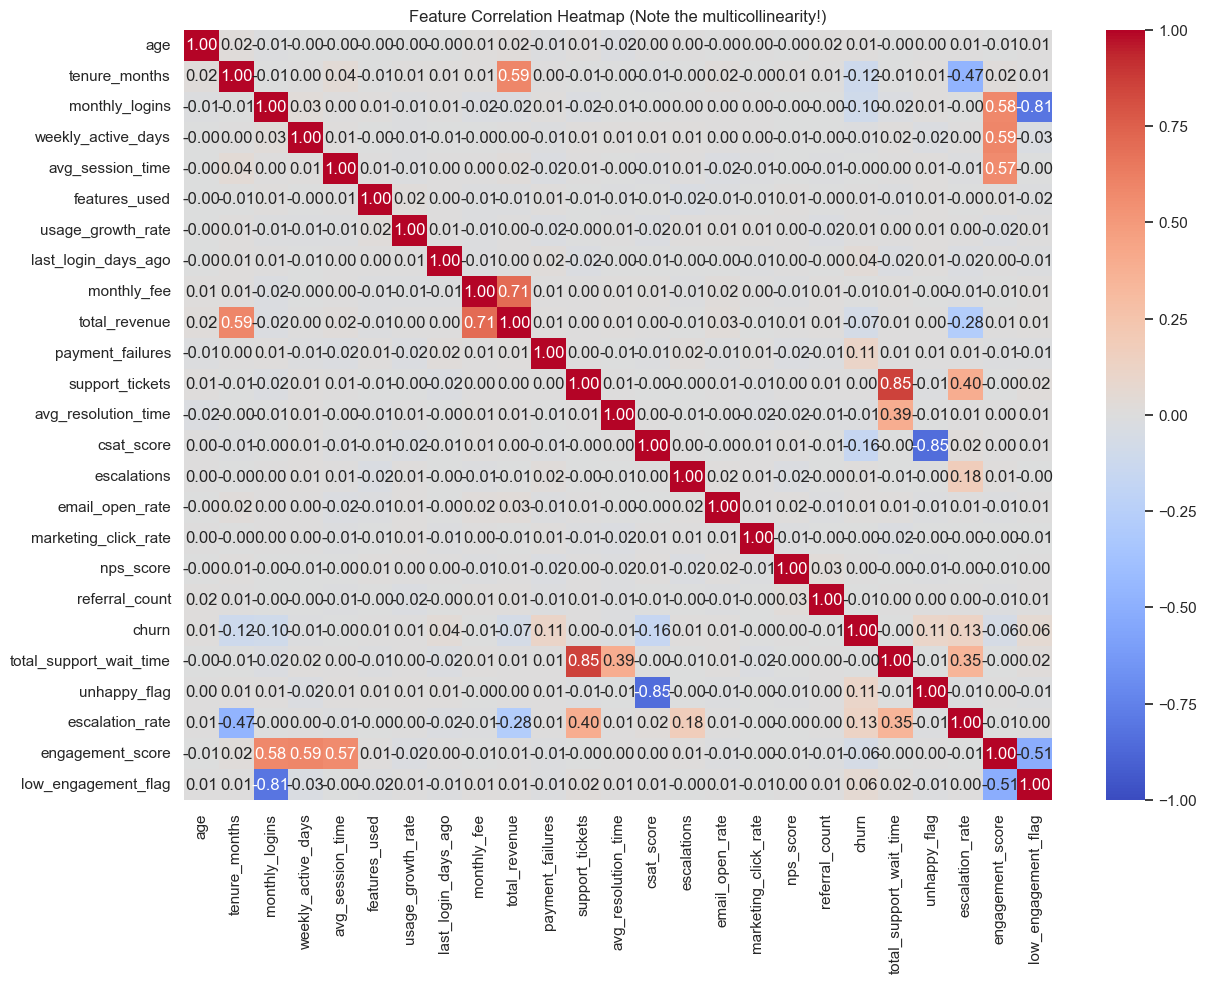

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))
# Select only numeric columns for correlation
numeric_df_for_corr = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df_for_corr.corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap (Note the multicollinearity!)")
plt.show()

### Feauter Engineering Class to fit in the Pipeline

In [51]:
class ChurnFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        # Variables to "memorize" training statistics for the API
        self.login_median_ = None
        self.weekly_active_median_ = None
        self.session_time_median_ = None
        
    def fit(self, X, y=None):
        # Memorize medians during training
        self.login_median_ = X["monthly_logins"].median()
        self.weekly_active_median_ = X["weekly_active_days"].median()
        self.session_time_median_ = X["avg_session_time"].median()
        return self
        
    def transform(self, X):
        X_new = X.copy()
        
        # 1. Total Support Wait Time
        X_new['total_support_wait_time'] = X_new['support_tickets'] * X_new['avg_resolution_time']
        
        # 2. Support Rate & Unhappy Flag
        X_new["unhappy_flag"] = (X_new["csat_score"] <= 3).astype(int)
        X_new["escalation_rate"] = (X_new["support_tickets"] + X_new["escalations"]) / (X_new["tenure_months"] + 1)
        
        # 3. Engagement Flags
        X_new["low_engagement_flag"] = (X_new["monthly_logins"] < self.login_median_).astype(int)
        
        score = (
            (X_new["monthly_logins"] >= self.login_median_).astype(int) +
            (X_new["weekly_active_days"] >= self.weekly_active_median_).astype(int) +
            (X_new["avg_session_time"] >= self.session_time_median_).astype(int)
        )
        X_new["engagement_score"] = score
        
        # 4. Fill Missing Complaints 
        X_new["complaint_type"] = X_new["complaint_type"].fillna("No_Complaint")
        
        # 5. Drop Customer ID if it exists
        if 'customer_id' in X_new.columns:
            X_new = X_new.drop(columns=['customer_id'])
            
        return X_new

## Encoding and Scaling

In [ ]:
# Using original df to do the transformaions again
X = df_original.drop(columns=["churn"])
y = df_original["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [53]:
numerical_columns_to_scale = [
    'age', 'tenure_months', 'monthly_fee', 'total_revenue', 
    'monthly_logins', 'weekly_active_days', 'avg_session_time', 
    'support_tickets', 'escalations', 'avg_resolution_time', 
    'csat_score', 'total_support_wait_time', 'escalation_rate', 
    'engagement_score'
]

categorical_columns = [
    'gender', 'country', 'customer_segment', 'contract_type', 
    'payment_method', 'complaint_type'
]

binary_columns_to_ignore = [
    'unhappy_flag', 'low_engagement_flag'
]

In [54]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first')) 
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_columns_to_scale),
        ('cat', categorical_transformer, categorical_columns),
        ('bin', 'passthrough', binary_columns_to_ignore) 
    ])

# Model Training

### Baseline Logistic Regression

In [55]:
lr_pipeline = Pipeline(steps=[
    ('feature_eng', ChurnFeatureEngineer()),
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=1))
])

lr_pipeline.fit(X_train, y_train)

d:\MachineLearning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_eng', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

### Evaluation

In [56]:
y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("--- Baseline Logistic Regression ---")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

print("\nTop Positive Churn Drivers:")
print(coef_df.head(15))

print("\nTop Negative Churn Drivers:")
print(coef_df.tail(15))

--- Baseline Logistic Regression ---
              precision    recall  f1-score   support

           0       0.94      0.69      0.80      2245
           1       0.19      0.63      0.29       255

    accuracy                           0.69      2500
   macro avg       0.57      0.66      0.55      2500
weighted avg       0.87      0.69      0.75      2500

ROC-AUC: 0.696117734398882

Top Positive Churn Drivers:
                        feature  coefficient
21              escalation_rate     0.415965
10             payment_failures     0.399876
38         customer_segment_SME     0.270664
22             engagement_score     0.218938
27              country_Germany     0.183947
50    survey_response_Satisfied     0.175385
51  survey_response_Unsatisfied     0.161879
34                city_New_York     0.161414
7           last_login_days_ago     0.142105
39      signup_channel_Referral     0.141748
37  customer_segment_Individual     0.128687
35                  city_Sydney     0.11

When escalation rate goes up the user tends to churn more, similarly the payment failiures also impact churning significantly

The csat_score is a strong indicator here, implying the score goes down, the user tends to stay

I built this Logistic Regression strictly as a baseline diagnostic tool, not a final product. It successfully caught 62% of our churners, but with a low precision of 20%, meaning it casts too wide of a net and creates too many false alarms. However, its real value is establishing a baseline ROC-AUC score of 0.72.

## Preliminary XGBoost

In [57]:


imbalance_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_pipeline = Pipeline(steps=[
    ('feature_eng', ChurnFeatureEngineer()),
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=imbalance_ratio,
        learning_rate=0.05,                
        max_depth=5,                      
        random_state=42,
        eval_metric='aucpr'
    ))
])

xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_eng', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

#### Evaluation

In [58]:
xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("\n--- Baseline XGBoost Performance ---")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))


--- Baseline XGBoost Performance ---
              precision    recall  f1-score   support

           0       0.95      0.79      0.86      2245
           1       0.26      0.64      0.36       255

    accuracy                           0.77      2500
   macro avg       0.60      0.71      0.61      2500
weighted avg       0.88      0.77      0.81      2500

ROC-AUC: 0.7403939036639153


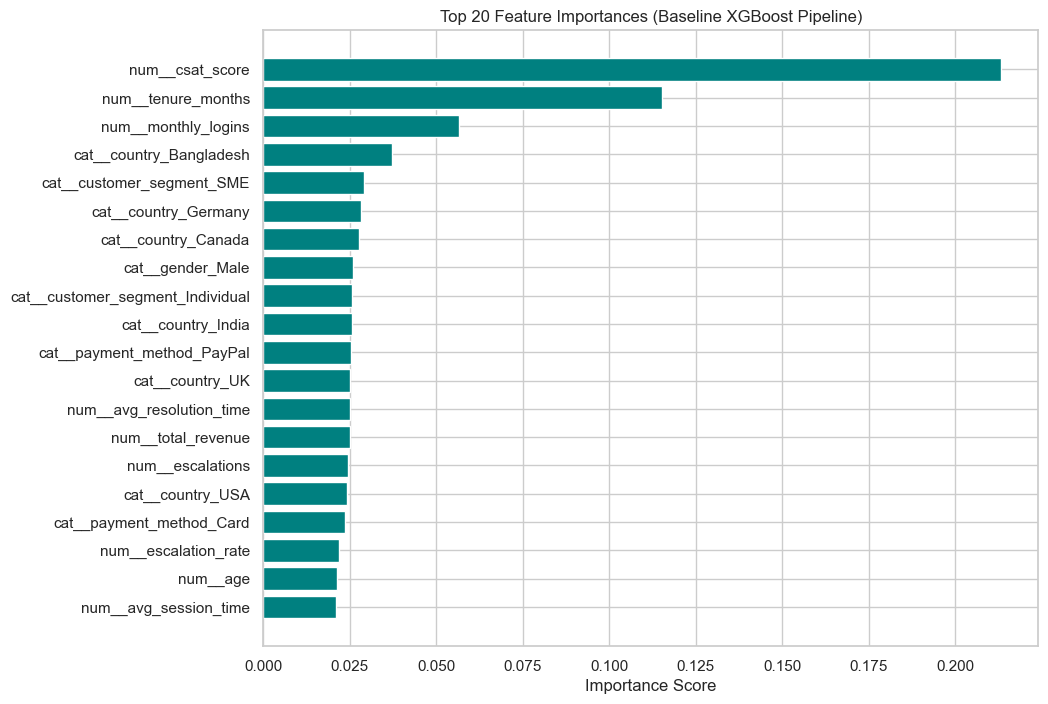

In [60]:
trained_xgb = xgb_pipeline.named_steps['classifier']
feature_names = xgb_pipeline.named_steps['preprocessor'].get_feature_names_out()

importance = trained_xgb.feature_importances_

imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
})


imp_df = imp_df.sort_values(by="importance", ascending=True).tail(20)

plt.figure(figsize=(10, 8))
plt.barh(imp_df["feature"], imp_df["importance"], color='teal')
plt.title("Top 20 Feature Importances (Baseline XGBoost Pipeline)")
plt.xlabel("Importance Score")
plt.show()

## XG Boost Optimization - GridSearch

In [62]:
param_grid = {
    'classifier__max_depth': [3, 4, 5],             
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__gamma': [0,0.25,1.0],
    'classifier__reg_lambda': [10,20,50], 
    'classifier__n_estimators': [100, 300]         
}

imbalance_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

# Initializ baseline eXGBoost 
xgb_to_tune = Pipeline(steps=[
    ('feature_eng', ChurnFeatureEngineer()),
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=imbalance_ratio, 
        random_state=42,
        eval_metric='aucpr'
    ))
])

# Set up the Grid Search
grid_search = GridSearchCV(
    estimator=xgb_to_tune,
    param_grid=param_grid,
    scoring='f1', 
    cv=3,        
    n_jobs=-1, 
    verbose=1   
)


print("\nStarting Grid Search...")
grid_search.fit(X_train, y_train)

print(f"Best parameters found: {grid_search.best_params_}")
best_xgb_pipeline = grid_search.best_estimator_

y_pred_opt = best_xgb_pipeline.predict(X_test)
y_proba_opt = best_xgb_pipeline.predict_proba(X_test)[:, 1]

print("\n--- Optimized XGBoost Performance ---")
print(classification_report(y_test, y_pred_opt))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_opt))


Starting Grid Search...
Fitting 3 folds for each of 162 candidates, totalling 486 fits
Best parameters found: {'classifier__gamma': 0, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 300, 'classifier__reg_lambda': 50}

--- Optimized XGBoost Performance ---
              precision    recall  f1-score   support

           0       0.96      0.76      0.85      2245
           1       0.26      0.72      0.38       255

    accuracy                           0.76      2500
   macro avg       0.61      0.74      0.61      2500
weighted avg       0.89      0.76      0.80      2500

ROC-AUC: 0.7628647539193851


In [ ]:
joblib.dump(best_xgb_pipeline, 'data/optimized_churn_model_pipeline.pkl')
print("\nPipeline saved successfully as 'churn_model_pipeline.pkl'")


Pipeline saved successfully as 'churn_model_pipeline.pkl'


## Model Comparision

### 1. Summary Table

In [65]:
models_eval = {
    "Baseline LR": {
        "pred": lr_pipeline.predict(X_test), 
        "proba": lr_pipeline.predict_proba(X_test)[:, 1]
    },
    "Baseline XGBoost": {
        "pred": xgb_pipeline.predict(X_test), 
        "proba": xgb_pipeline.predict_proba(X_test)[:, 1]
    },
    "Optimized XGBoost": {
        "pred": best_xgb_pipeline.predict(X_test), 
        "proba": best_xgb_pipeline.predict_proba(X_test)[:, 1]
    }
}

metrics_list = []
for name, data in models_eval.items():
    metrics_list.append({
        "Model": name,
        "ROC-AUC": roc_auc_score(y_test, data["proba"]),
        "Recall (Catch Rate)": recall_score(y_test, data["pred"]),
        "Precision (Accuracy of Flags)": precision_score(y_test, data["pred"]),
        "F1-Score": f1_score(y_test, data["pred"])
    })

metrics_df = pd.DataFrame(metrics_list).set_index("Model")
print("--- FINAL MODEL COMPARISON ---")
display(metrics_df.round(3))

--- FINAL MODEL COMPARISON ---


,ROC-AUC,Recall (Catch Rate),Precision (Accuracy of Flags),F1-Score
Model,,,,
Baseline LR,0.696,0.631,0.190,0.292
Baseline XGBoost,0.740,0.635,0.256,0.364
Optimized XGBoost,0.763,0.722,0.255,0.377


### 2. Comparssion Plots

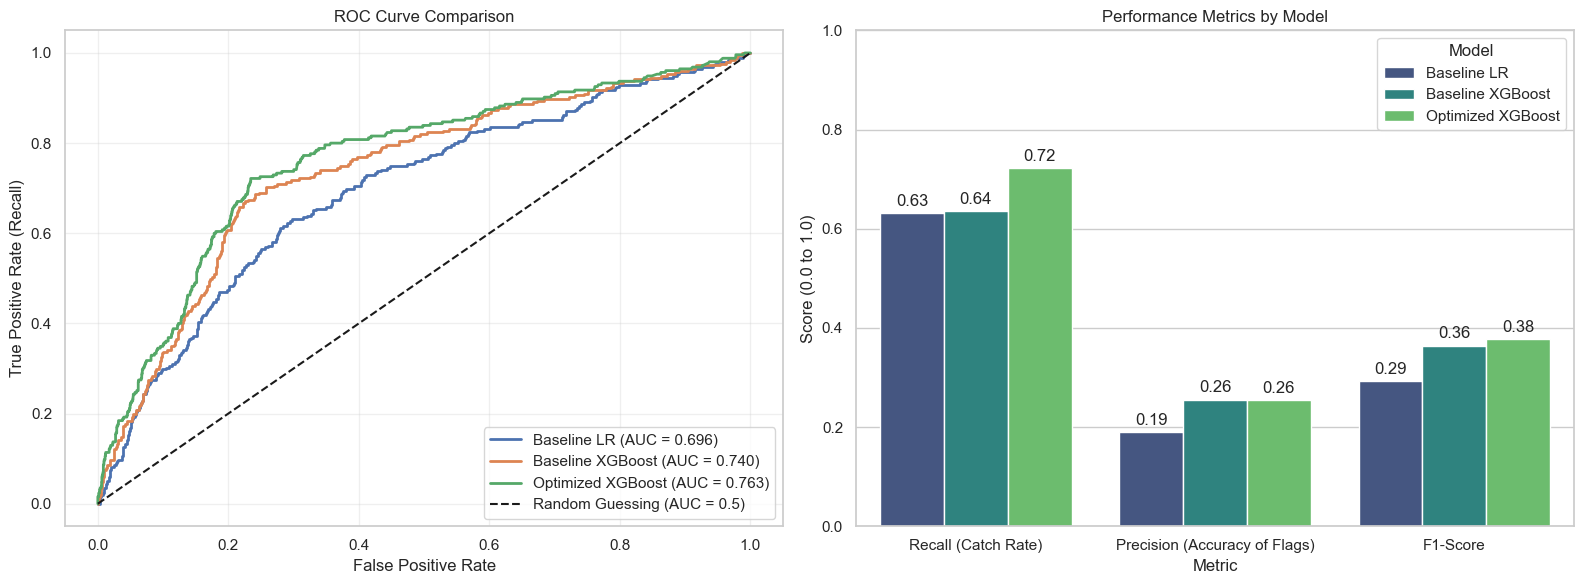

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Combined ROC Curve 
for name, data in models_eval.items():
    fpr, tpr, _ = roc_curve(y_test, data["proba"])
    auc_score = roc_auc_score(y_test, data["proba"])
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', lw=2)

axes[0].plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.5)')
axes[0].set_title('ROC Curve Comparison')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Metric Bar Chart 
metrics_melted = metrics_df.drop(columns=['ROC-AUC']).reset_index().melt(
    id_vars='Model', var_name='Metric', value_name='Score'
)

sns.barplot(data=metrics_melted, x='Metric', y='Score', hue='Model', palette='viridis', ax=axes[1])
axes[1].set_title('Performance Metrics by Model')
axes[1].set_ylabel('Score (0.0 to 1.0)')
axes[1].set_ylim(0, 1)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

#### 3. Conusion Matrices

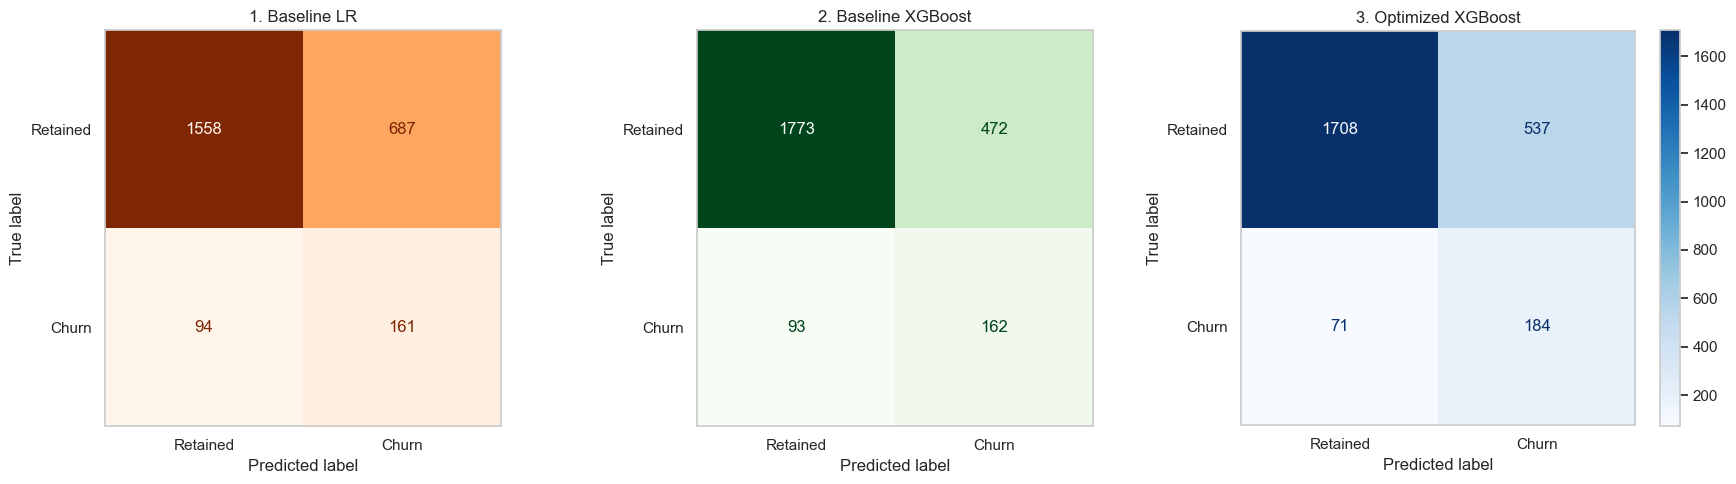

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Baseline LR
ConfusionMatrixDisplay.from_estimator(
    lr_pipeline, X_test, y_test, 
    values_format='d', cmap='Oranges', ax=axes[0], colorbar=False, display_labels=['Retained', 'Churn']
)
axes[0].set_title("1. Baseline LR")
axes[0].grid(False)

# 2. Baseline XGBoost
ConfusionMatrixDisplay.from_estimator(
    xgb_pipeline, X_test, y_test, 
    values_format='d', cmap='Greens', ax=axes[1], colorbar=False, display_labels=['Retained', 'Churn']
)
axes[1].set_title("2. Baseline XGBoost")
axes[1].grid(False)

# 3. Optimized XGBoost
ConfusionMatrixDisplay.from_estimator(
    best_xgb_pipeline, X_test, y_test, 
    values_format='d', cmap='Blues', ax=axes[2], colorbar=True, display_labels=['Retained', 'Churn']
)
axes[2].set_title("3. Optimized XGBoost")
axes[2].grid(False)

plt.tight_layout()
plt.show()

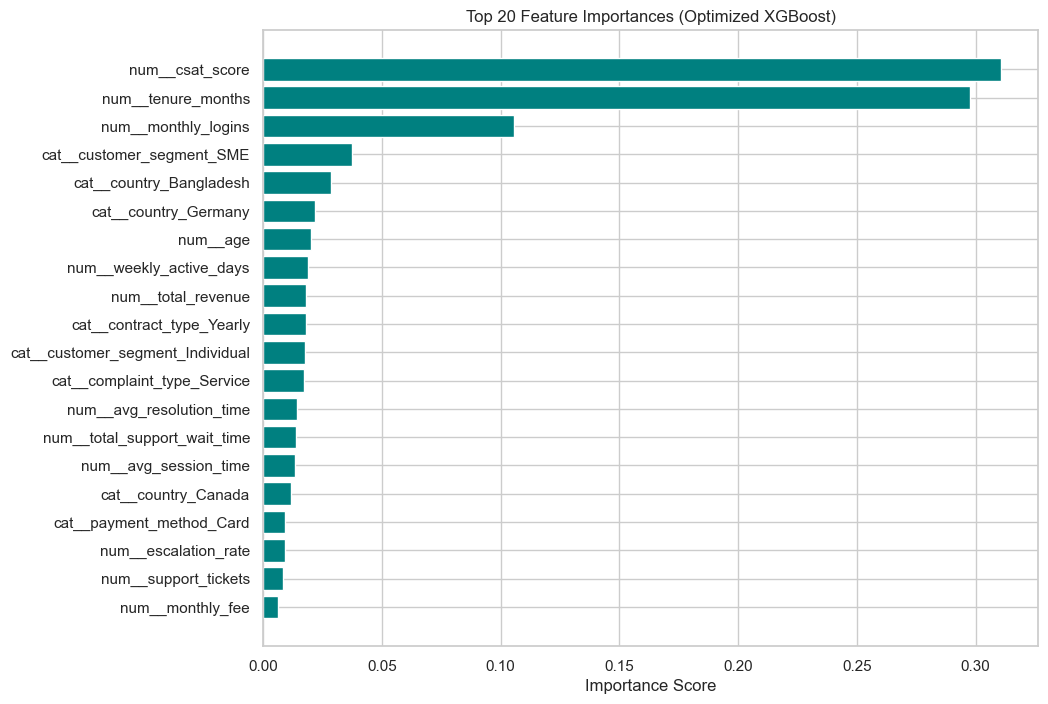


--- EXECUTIVE SUMMARY: FINANCIAL IMPACT ---
--- Business Impact: Baseline Logistic Regression ---
Cost of doing nothing (All churners leave): $127,500
Cost incurred using model (Missed + Campaigns): $89,400
Total Money SAVED by using this model: $38,100

--- Business Impact: Optimized XGBoost ---
Cost of doing nothing (All churners leave): $127,500
Cost incurred using model (Missed + Campaigns): $71,550
Total Money SAVED by using this model: $55,950



In [64]:
trained_xgb = best_xgb_pipeline.named_steps['classifier']
feature_names = best_xgb_pipeline.named_steps['preprocessor'].get_feature_names_out()

imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": trained_xgb.feature_importances_
}).sort_values(by="importance", ascending=True).tail(20) 

plt.figure(figsize=(10, 8))
plt.barh(imp_df["feature"], imp_df["importance"], color='teal')
plt.title("Top 20 Feature Importances (Optimized XGBoost)")
plt.xlabel("Importance Score")
plt.show()

# 2. Business Impact Evaluation
def calculate_business_impact(y_true, y_pred, model_name):
    cost_fn = 500  # Cost of missed churner (Lost revenue)
    cost_fp = 50   # Cost of false alarm (Wasted retention discount)
    cost_tp = 50   # Cost to save a churner (Cost of discount)
    cost_tn = 0    # Happy customer (No cost)

    from sklearn.metrics import confusion_matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    total_cost = (fn * cost_fn) + (fp * cost_fp) + (tp * cost_tp) + (tn * cost_tn)
    cost_of_doing_nothing = (fn + tp) * cost_fn
    savings = cost_of_doing_nothing - total_cost
    
    print(f"--- Business Impact: {model_name} ---")
    print(f"Cost of doing nothing (All churners leave): ${cost_of_doing_nothing:,}")
    print(f"Cost incurred using model (Missed + Campaigns): ${total_cost:,}")
    print(f"Total Money SAVED by using this model: ${savings:,}\n")

print("\n--- EXECUTIVE SUMMARY: FINANCIAL IMPACT ---")
calculate_business_impact(y_test, y_pred_lr, "Baseline Logistic Regression")
calculate_business_impact(y_test, y_pred_opt, "Optimized XGBoost")